# Fine tuning the hyperparameters of regular ML models in scikit-learn

In [2]:
# data manipulation libraries
import numpy as np
import pandas as pd

# data visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# machine learning tools
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,\
                            recall_score, precision_score, f1_score
import time

# models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

In [3]:
# loading the dataset into a dataframe
attrition = pd.read_csv(r'Generated data/attrition.csv')
print(f"The data has {attrition.shape[0]} rows and {attrition.shape[1]} columns.")
attrition.sample(5)

The data has 2000001 rows and 12 columns.


,ee#,age,department,province,level,gender,ethnicity,hire_source,promotion,tenure,previous_xp,total_xp
34842,10034842,42,Project Management,New Brunswick,Individual contributor,male,bi-racial,referral,not_promoted,6.0,11.0,17.0
801311,10801311,68,Legal,Manitoba,Individual contributor,female,caucasian,direct,not_promoted,3.9,17.6,21.5
614768,10614768,60,Sales,Alberta,Individual contributor,male,caucasian,referral,promoted,17.4,11.4,28.8
332614,10332614,43,Sales,Nunavut,Manager/Director,non-binary,caucasian,direct,promoted,7.1,10.9,18.0
343549,10343549,42,Marketing,New Brunswick,Individual contributor,female,caucasian,referral,promoted,9.7,7.3,17.0


In [4]:
# getting basic information about the data
summary = []

for i in attrition.columns:
    column_info = {}
    column_info['name'] = attrition[i].name
    column_info['data type'] = attrition[i].dtypes
    column_info['example'] = attrition[i].iloc[0]
    column_info['unique#'] = attrition[i].nunique()
    summary.append(column_info)

summary = pd.DataFrame(summary)
summary

,name,data type,example,unique#
0,ee#,int64,10000000,2000001
1,age,int64,60,46
2,department,object,HR,8
3,province,object,Nova Scotia,13
4,level,object,Individual contributor,3
5,gender,object,female,3
6,ethnicity,object,caucasian,8
7,hire_source,object,agency,3
8,promotion,object,not_promoted,2
9,tenure,float64,16.7,1226


## Dataframe preparation

In [6]:
# creating a value to be predicted
# 1. initializing target variable
num_samples= len(attrition)
status = np.random.choice(a= ['active', 'left'],
                          size= num_samples,
                          p= [0.6, 0.4])

# 2. introducing subtle patterns in the data
for i in range(num_samples):
    if attrition['department'][i] == 'Project Management':
        status[i] = 'left' if np.random.rand() < 0.40 else status[i]
    if attrition['age'][i] > 50:
        status[i] = 'left' if np.random.rand() < 0.40 else status[i]
    if attrition['hire_source'][i] == 'direct':
        status[i] = 'left' if np.random.rand() < 0.40 else status[i]
    if attrition['province'][i] == 'Alberta':
        status[i] = 'left' if np.random.rand() < 0.40 else status[i]

attrition['status'] = status

The target is initialized with a 60/40 ratio of active/left employees for starters, then providing more left cases based on the parameters below.
- Employees in 'Project Management'
- Employees above 50
- Employees hired directly
- Employees in Alberta

In [8]:
# checking what ratios we're working with

# 1. isolating the rows where the patterns was introduced
check_age = attrition.loc[attrition['age'] > 50]
check_department = attrition.loc[attrition['department'] == 'Project Management']
check_source = attrition.loc[attrition['hire_source'] == 'direct']
check_province = attrition.loc[attrition['province'] == 'Alberta']

all_checks = [check_age, check_department, check_province, check_source]
predictor_names = ['age', 'department', 'province', 'hire source']

# 2. output the ratio for each
for var, name in zip(all_checks, predictor_names):
    print(f"% of left vs active employees for predictor '{name}'")
    print(var['status'].value_counts(normalize= True).mul(100).round(1).astype(str)+'%')
    print()

% of left vs active employees for predictor 'age'
status
left      73.5%
active    26.5%
Name: proportion, dtype: object

% of left vs active employees for predictor 'department'
status
left      77.0%
active    23.0%
Name: proportion, dtype: object

% of left vs active employees for predictor 'province'
status
left      77.5%
active    22.5%
Name: proportion, dtype: object

% of left vs active employees for predictor 'hire source'
status
left      72.6%
active    27.4%
Name: proportion, dtype: object



So on average we have about 75% of left employees for each predictor to train our model.
Now let's prepare the data for the training.

In [10]:
# breaking down the dataframe into binary predictors
attr_dummy_df= pd.get_dummies(data= attrition,
                             dtype= 'float64')
attr_dummy_df= attr_dummy_df.drop(columns=['status_left','promotion_not_promoted'],
                                  axis=1)
attr_dummy_df= attr_dummy_df.rename(columns={'promotion_promoted':'promotion',
                                             'status_active':'status'})

# highlighting the columns that were broken down because they were categorical originally
for i in attrition.columns:
    if pd.api.types.is_string_dtype(attrition[i]):
        print(f"Column '{i}' was broken down into:")
        print(attrition[i].unique())
        print()
    else:
        continue

attr_dummy_df.sample(5)

Column 'department' was broken down into:
['HR' 'Project Management' 'IT' 'Finance' 'Legal' 'Marketing'
 'Customer Service' 'Sales']

Column 'province' was broken down into:
['Nova Scotia' 'Newfoundland and Labrador' 'Northwest Territories'
 'Manitoba' 'Nunavut' 'Quebec' 'New Brunswick' 'Ontario'
 'British Columbia' 'Prince Edward Island' 'Alberta' 'Yukon Territory'
 'Saskatchewan']

Column 'level' was broken down into:
['Individual contributor' 'Manager/Director' 'Senior Leadership']

Column 'gender' was broken down into:
['female' 'male' 'non-binary']

Column 'ethnicity' was broken down into:
['caucasian' 'asian' 'hispanic' 'african descent' 'bi-racial'
 'middle eastern' 'pacific islander' 'indigenous']

Column 'hire_source' was broken down into:
['agency' 'direct' 'referral']

Column 'promotion' was broken down into:
['not_promoted' 'promoted']

Column 'status' was broken down into:
['active' 'left']



,ee#,age,tenure,previous_xp,total_xp,department_Customer Service,department_Finance,department_HR,department_IT,department_Legal,...,ethnicity_caucasian,ethnicity_hispanic,ethnicity_indigenous,ethnicity_middle eastern,ethnicity_pacific islander,hire_source_agency,hire_source_direct,hire_source_referral,promotion,status
477228,10477228,56,9.4,11.3,20.7,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0
530028,10530028,46,2.9,18.1,21.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1405079,11405079,34,10.8,0.0,10.8,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
297886,10297886,64,15.5,20.8,36.3,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1695383,11695383,69,25.6,0.2,25.8,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0


In [11]:
# OPTIONAL: simplifying down the df to our patterns for better readability
# two columns per predictor
simplified_dummy = attr_dummy_df[['ee#', 'age',
                                  'department_IT', 'department_Project Management',
                                  'province_Nunavut', 'province_Alberta', 
                                  'hire_source_agency', 'hire_source_direct',
                                  'promotion', 'status']]
simplified_dummy.sample(5)

,ee#,age,department_IT,department_Project Management,province_Nunavut,province_Alberta,hire_source_agency,hire_source_direct,promotion,status
1578342,11578342,61,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
484786,10484786,45,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
1405298,11405298,67,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1909487,11909487,28,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
487767,10487767,38,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0


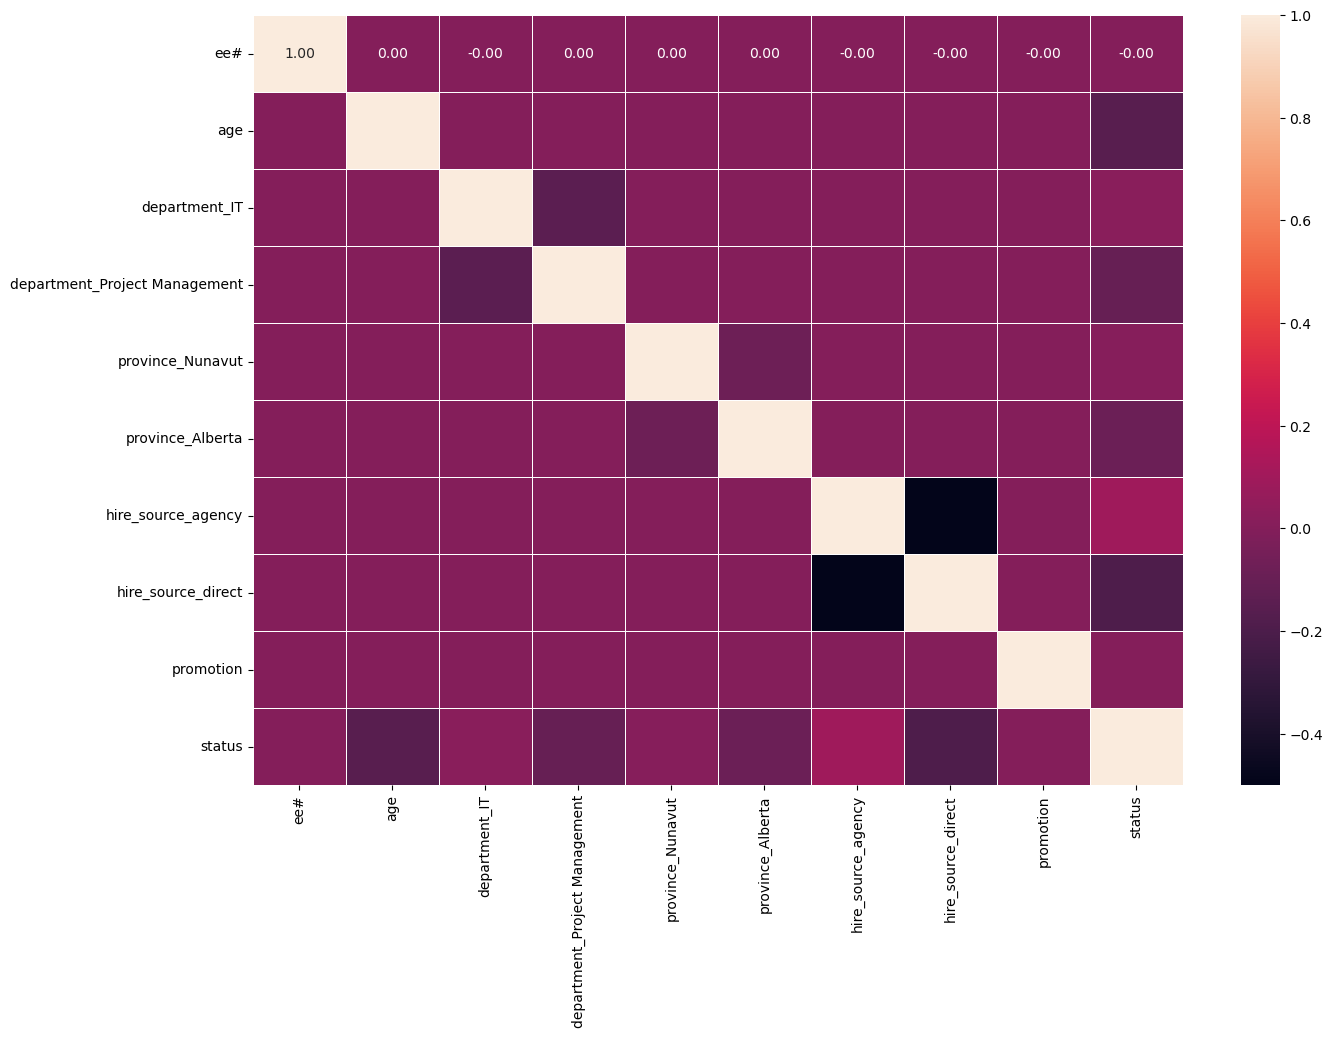

In [12]:
# correlation matrix
attr_corr_matrix= simplified_dummy.corr()
plt.figure(figsize=(15,10))
sns.heatmap(attr_corr_matrix, 
            annot= True,
            linewidths= 0.5,
            fmt= ".2f")
plt.show();

## Data splitting and model initializations

In [14]:
# separating target variables from features with patterns
X_dept= pd.DataFrame(attr_dummy_df['department_Project Management'])
X_age= pd.DataFrame(attr_dummy_df['age'])
X_source= pd.DataFrame(attr_dummy_df['hire_source_direct'])
X_province= pd.DataFrame(attr_dummy_df['province_Alberta'])

y= attr_dummy_df['status']

Breaking down the hire source predictor we are focusing on for now into train, validation and test sets. 
To do this, we will use `train_test_split` twice
1. 80% train + validation / 20% test
2. 70% train / 30% validation

Final proportions will be:
- Test 20%
- Validation 24%
- Training 56%

In [16]:
# splitting source predictor into train + validation vs test data
X_remainder_source, X_test_source, y_remainder_source, y_test_source = \
        train_test_split(X_source, y, train_size= 0.8, test_size= 0.2)

# splitting source predictor into train vs validation data
X_train_source, X_validation_source, y_train_source, y_validation_source = \
        train_test_split(X_remainder_source, y_remainder_source,
                         train_size= 0.7, test_size= 0.3)

In [17]:
# checking size of each sets
print(f'Shape of test set: {X_test_source.shape[0]} items, or {(X_test_source.shape[0] / X_source.shape[0]*100):0.2f}% of the data.')
print(f"Ratio of terminated vs active employees in test set: \n{y_test_source.value_counts(normalize= True).mul(100).round(2).astype(str)+'%'}")
print()
print(f'Shape of validation set: {X_validation_source.shape[0]} items, or {(X_validation_source.shape[0] / X_source.shape[0]*100):0.2f}% of the data.')
print(f"Ratio of terminated vs active employees in validation set: \n{y_validation_source.value_counts(normalize= True).mul(100).round(2).astype(str)+'%'}")
print()
print(f'Shape of train set: {X_train_source.shape[0]} items, or {(X_train_source.shape[0] / X_source.shape[0]*100):0.2f}% of the data.')
print(f"Ratio of terminated vs active employees in test set: \n{y_train_source.value_counts(normalize= True).mul(100).round(2).astype(str)+'%'}")

Shape of test set: 400001 items, or 20.00% of the data.
Ratio of terminated vs active employees in test set: 
status
0.0    63.56%
1.0    36.44%
Name: proportion, dtype: object

Shape of validation set: 480000 items, or 24.00% of the data.
Ratio of terminated vs active employees in validation set: 
status
0.0    63.4%
1.0    36.6%
Name: proportion, dtype: object

Shape of train set: 1120000 items, or 56.00% of the data.
Ratio of terminated vs active employees in test set: 
status
0.0    63.53%
1.0    36.47%
Name: proportion, dtype: object


## Cross validation of the Logistic Regression model

In [19]:
# Initialize-Fit-Score
C_range = np.array([.00000001,.0000001,.000001,.00001,.0001,.001,0.1,\
                    1,10,100,1000,10000,100000,1000000,10000000,\
                    100000000,1000000000])
lr_training_scores = []
lr_validation_scores = []
LR_evaluation = []

# evaluating different Cs on the model & timing execution
overall_start_time = time.time()

for c in C_range:
    iteration_info = {}
    local_start_time = time.time()
    
    # fitting the model
    cross_logreg = LogisticRegression(C= c)
    cross_logreg.fit(X_train_source, y_train_source)

    # training & scoring on validation
    train_score = cross_logreg.score(X_train_source,
                                     y_train_source)
    validation_score = cross_logreg.score(X_validation_source,
                                          y_validation_source)
    local_end_time = time.time()
    lr_training_scores.append(train_score)
    lr_validation_scores.append(validation_score)
    iteration_info['Parameter'] = f"Regularization {c:.2e}"
    iteration_info['Speed'] = local_end_time - local_start_time
    iteration_info['Training'] = f"{train_score *100:.2f}%"
    iteration_info['Validation'] = f"{validation_score *100:.2f}%"
    LR_evaluation.append(iteration_info)

overall_end_time = time.time()

print(f"Full testing of the Logistic Regression took {overall_end_time - overall_start_time:.6f} seconds")
LR_evaluation = pd.DataFrame(LR_evaluation).sort_values(by= ['Speed'],
                                                        ascending= True)
LR_evaluation

Full testing of the Logistic Regression took 7.309860 seconds


,Parameter,Speed,Training,Validation
2,Regularization 1.00e-06,0.333997,63.53%,63.40%
1,Regularization 1.00e-07,0.348050,63.53%,63.40%
0,Regularization 1.00e-08,0.379352,63.53%,63.40%
4,Regularization 1.00e-04,0.441563,63.53%,63.40%
5,Regularization 1.00e-03,0.443810,63.53%,63.40%
9,Regularization 1.00e+02,0.444489,63.53%,63.40%
14,Regularization 1.00e+07,0.445164,63.53%,63.40%
3,Regularization 1.00e-05,0.445638,63.53%,63.40%
16,Regularization 1.00e+09,0.445771,63.53%,63.40%
12,Regularization 1.00e+05,0.446903,63.53%,63.40%


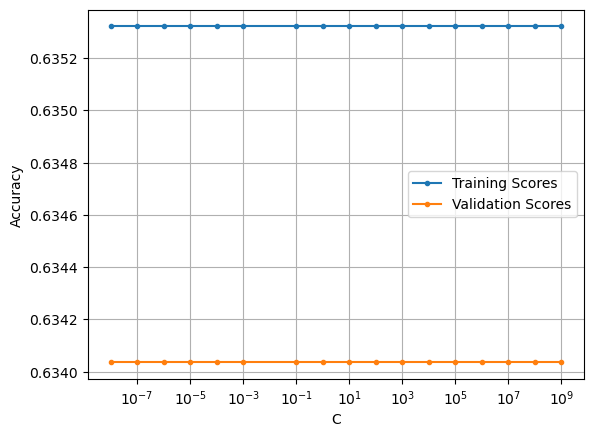

In [20]:
# plotting the training and validation scores for visualization
plt.figure()
plt.plot(C_range, lr_training_scores,
         label="Training Scores", marker='.')
plt.plot(C_range, lr_validation_scores,
         label="Validation Scores", marker='.')
plt.xscale('log')
plt.grid()
plt.xlabel('C')
plt.ylabel('Accuracy')
plt.legend()
plt.show();

In [21]:
# isolating the fastest 3 settings for regularization
LR_evaluation.nsmallest(n= 3, columns= 'Speed')

,Parameter,Speed,Training,Validation
2,Regularization 1.00e-06,0.333997,63.53%,63.40%
1,Regularization 1.00e-07,0.348050,63.53%,63.40%
0,Regularization 1.00e-08,0.379352,63.53%,63.40%


In [ ]:
# Initialize-Fit-Score a GridSearch to combine tuning 
# parameters are: 
# 10 cross validations, 7 values of C & 2 values of penalty
grid_values = {
    'penalty': ['l1','l2'],
    'C': C_range
}
logreg = LogisticRegression()

grid_logreg = GridSearchCV(estimator= logreg, 
                           param_grid = grid_values,
                           n_jobs= -1,
                           cv= 10,
                           verbose= 3)
            
grid_logreg.fit(X_train_source, y_train_source)

In [23]:
best_parameters_logreg = grid_logreg.best_params_
best_parameters_logreg

{'C': 1e-08, 'penalty': 'l2'}

In [24]:
# Predict values based on best parameters from GridSearch
test_logreg = LogisticRegression(C= 1e-08,
                                 penalty= 'l2')
test_logreg.fit(X= X_train_source,
                y= y_train_source)

y_pred_source_tested = test_logreg.predict(X_test_source)

print('Accuracy Score : ' + str(accuracy_score(y_true= y_test_source,
                                               y_pred= y_pred_source_tested)))
print('Precision Score : ' + str(precision_score(y_true= y_test_source,
                                                 y_pred= y_pred_source_tested)))
print('Recall Score : ' + str(recall_score(y_true= y_test_source,
                                           y_pred= y_pred_source_tested)))
print('F1 Score : ' + str(f1_score(y_true= y_test_source,
                                   y_pred= y_pred_source_tested)))

#Logistic Regression (Grid Search) Confusion matrix
test_cm_array = confusion_matrix(y_true= y_test_source,
                                 y_pred= y_pred_source_tested)

# Convert confusion matrix to DataFrame
cm_test = pd.DataFrame(test_cm_array, 
                     index=['Actual Left', 'Actual Active'], 
                     columns=['Predicted Left', 'Predicted Active'])
cm_test

Accuracy Score : 0.6355559111102222
Precision Score : 0.0
Recall Score : 0.0
F1 Score : 0.0


,Predicted Left,Predicted Active
Actual Left,254223,0
Actual Active,145778,0


## Cross validation of the Decision Tree model

In [26]:
# Initialize-Fit-Score
DT_depth = range(5, 51, 5)
DT_train_scores = []
DT_vali_scores = []
DT_evaluation = []

overall_start_time = time.time()
for d in DT_depth:
    iteration_info = {}
    local_start_time = time.time()
    cross_DT = DecisionTreeClassifier(max_depth= d)
    cross_DT.fit(X_train_source, y_train_source)
    
    # training & scoring on validation
    train_score = cross_DT.score(X_train_source,
                                 y_train_source)
    
    validation_score = cross_DT.score(X_validation_source,
                                      y_validation_source)
    local_end_time = time.time()
    DT_train_scores.append(train_score)
    DT_vali_scores.append(validation_score)
    iteration_info['Parameter'] = f"Max depth {d}"
    iteration_info['Speed'] = local_end_time - local_start_time
    iteration_info['Training'] = f"{train_score *100:.2f}%"
    iteration_info['Validation'] = f"{validation_score *100:.2f}%"
    DT_evaluation.append(iteration_info)

overall_end_time = time.time()
print(f"Full testing of the Decision Tree took {overall_end_time - overall_start_time:.6f} seconds")
DT_evaluation = pd.DataFrame(DT_evaluation).sort_values(by= ['Speed'],
                                                        ascending= True)
DT_evaluation

Full testing of the Decision Tree took 2.498868 seconds


,Parameter,Speed,Training,Validation
5,Max depth 30,0.247513,63.53%,63.40%
9,Max depth 50,0.248094,63.53%,63.40%
3,Max depth 20,0.248357,63.53%,63.40%
4,Max depth 25,0.249224,63.53%,63.40%
8,Max depth 45,0.249517,63.53%,63.40%
1,Max depth 10,0.249572,63.53%,63.40%
7,Max depth 40,0.249849,63.53%,63.40%
6,Max depth 35,0.249972,63.53%,63.40%
2,Max depth 15,0.250763,63.53%,63.40%
0,Max depth 5,0.255792,63.53%,63.40%


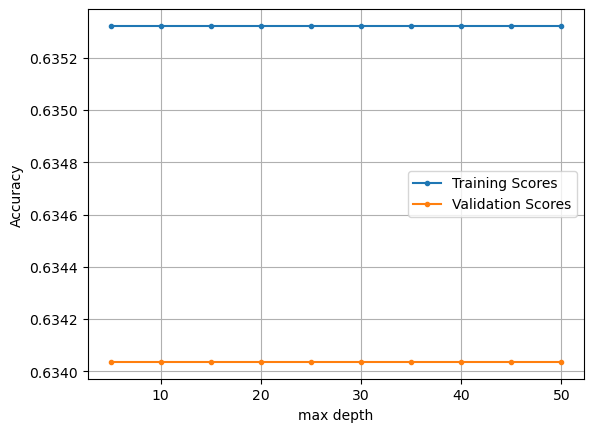

In [27]:
# plotting the training and validation scores for visualization
plt.figure()
plt.plot(DT_depth, DT_train_scores,
         label="Training Scores", marker='.')
plt.plot(DT_depth, DT_vali_scores,
         label="Validation Scores", marker='.')
plt.grid()
plt.xlabel('max depth')
plt.ylabel('Accuracy')
plt.legend()
plt.show();

In [28]:
# isolating the fastest 3 parameters
DT_evaluation.nsmallest(n= 3, columns= 'Speed')

,Parameter,Speed,Training,Validation
5,Max depth 30,0.247513,63.53%,63.40%
9,Max depth 50,0.248094,63.53%,63.40%
3,Max depth 20,0.248357,63.53%,63.40%


In [ ]:
# Initialize-Fit-Score a GridSearch to combine tuning 
# parameters are: 10 cross validations, 9 values of tree depth, 
# 2 values of criterion & 2 types of splitters
DT_depth = range(5, 51, 5)
criterion_list = ['gini', 'entropy']
splitter_list = ['best', 'random']

grid_values_DT = {
    'max_depth': DT_depth,
    'criterion': criterion_list,
    'splitter': splitter_list,
}
DT = DecisionTreeClassifier()

grid_DT = GridSearchCV(estimator= DT, 
                       param_grid = grid_values_DT,
                       n_jobs= -1,
                       cv= 10,
                       verbose= 3)
            
grid_DT.fit(X_train_source, y_train_source)

In [30]:
best_parameters_DT = grid_DT.best_params_
best_parameters_DT

{'criterion': 'gini', 'max_depth': 5, 'splitter': 'best'}

In [31]:
# Predict values based on best parameters from GridSearch
y_pred_source = grid_DT.predict(X_validation_source)

print('Accuracy Score : ' + str(accuracy_score(y_validation_source,
                                               y_pred_source)))
print('Precision Score : ' + str(precision_score(y_validation_source,
                                                 y_pred_source)))
print('Recall Score : ' + str(recall_score(y_validation_source,
                                           y_pred_source)))
print('F1 Score : ' + str(f1_score(y_validation_source,
                                   y_pred_source)))

#Logistic Regression (Grid Search) Confusion matrix
cm_array = confusion_matrix(y_validation_source,
                             y_pred_source)

# Convert confusion matrix to DataFrame
cm_df = pd.DataFrame(cm_array, index=['Actual Left', 'Actual Active'], 
                     columns=['Predicted Left', 'Predicted Active'])
cm_df

Accuracy Score : 0.6340354166666666
Precision Score : 0.0
Recall Score : 0.0
F1 Score : 0.0


,Predicted Left,Predicted Active
Actual Left,304337,0
Actual Active,175663,0


## Cross validation of the Gaussian model

In [33]:
# Initialize-Fit-Score
smooth_var = np.logspace(0, -9)
NB_train_scores = []
NB_vali_scores = []
NB_evaluation = []

overall_start_time = time.time()
for smooth in smooth_var:
    iteration_info = {}
    local_start_time = time.time()
    cross_NB = GaussianNB(var_smoothing= smooth)
    cross_NB.fit(X_train_source, y_train_source)
    
    # training & scoring on validation
    train_score = cross_NB.score(X_train_source,
                                 y_train_source)
    
    validation_score = cross_NB.score(X_validation_source,
                                      y_validation_source)
    local_end_time = time.time()
    NB_train_scores.append(train_score)
    NB_vali_scores.append(validation_score)
    iteration_info['Parameter'] = f"Var smoothing {smooth}"
    iteration_info['Speed'] = local_end_time - local_start_time
    iteration_info['Training'] = f"{train_score *100:.2f}%"
    iteration_info['Validation'] = f"{validation_score *100:.2f}%"
    NB_evaluation.append(iteration_info)

overall_end_time = time.time()
print(f"Full testing of the Gaussian Classifier took {overall_end_time - overall_start_time:.6f} seconds")
NB_evaluation = pd.DataFrame(NB_evaluation).sort_values(by= ['Speed'],
                                                        ascending= True)
NB_evaluation

Full testing of the Gaussian Classifier took 11.347315 seconds


,Parameter,Speed,Training,Validation
37,Var smoothing 1.5998587196060574e-07,0.221628,63.53%,63.40%
36,Var smoothing 2.4420530945486497e-07,0.221788,63.53%,63.40%
14,Var smoothing 0.0026826957952797246,0.222207,63.53%,63.40%
35,Var smoothing 3.727593720314938e-07,0.222403,63.53%,63.40%
30,Var smoothing 3.0888435964774785e-06,0.222454,63.53%,63.40%
39,Var smoothing 6.866488450042998e-08,0.222496,63.53%,63.40%
34,Var smoothing 5.689866029018293e-07,0.222974,63.53%,63.40%
12,Var smoothing 0.0062505519252739694,0.223194,63.53%,63.40%
45,Var smoothing 5.4286754393238595e-09,0.223288,63.53%,63.40%
33,Var smoothing 8.685113737513521e-07,0.223303,63.53%,63.40%


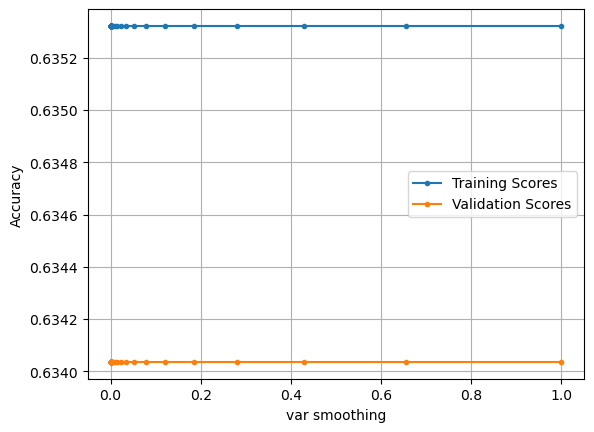

In [34]:
# plotting the training and validation scores for visualization
plt.figure()
plt.plot(smooth_var, NB_train_scores,
         label="Training Scores", marker='.')
plt.plot(smooth_var, NB_vali_scores,
         label="Validation Scores", marker='.')
plt.grid()
plt.xlabel('var smoothing')
plt.ylabel('Accuracy')
plt.legend()
plt.show();

In [35]:
# isolating the fastest 3 parameters
NB_evaluation.nsmallest(n= 3, columns= 'Speed')

,Parameter,Speed,Training,Validation
37,Var smoothing 1.5998587196060574e-07,0.221628,63.53%,63.40%
36,Var smoothing 2.4420530945486497e-07,0.221788,63.53%,63.40%
14,Var smoothing 0.0026826957952797246,0.222207,63.53%,63.40%


In [ ]:
# Initialize-Fit-Score a GridSearch to combine tuning 
# parameters are: 10 cross validations & 50 values of var smoothing
grid_values_NB = {
    'var_smoothing': smooth_var
}
NB = GaussianNB()

grid_NB = GridSearchCV(estimator= NB, 
                       param_grid= grid_values_NB,
                       n_jobs= -1,
                       cv= 10,
                       verbose= 3)
            
grid_NB.fit(X_train_source, y_train_source)

In [37]:
best_parameters_NB = grid_NB.best_params_
best_parameters_NB

{'var_smoothing': 1.0}

In [38]:
# Predict values based on best parameters from GridSearch
y_pred_source = grid_NB.predict(X_validation_source)

print('Accuracy Score : ' + str(accuracy_score(y_validation_source,
                                               y_pred_source)))
print('Precision Score : ' + str(precision_score(y_validation_source,
                                                 y_pred_source)))
print('Recall Score : ' + str(recall_score(y_validation_source,
                                           y_pred_source)))
print('F1 Score : ' + str(f1_score(y_validation_source,
                                   y_pred_source)))

#Logistic Regression (Grid Search) Confusion matrix
cm_array = confusion_matrix(y_validation_source,
                             y_pred_source)

# Convert confusion matrix to DataFrame
cm_df = pd.DataFrame(cm_array, index=['Actual Left', 'Actual Active'], 
                     columns=['Predicted Left', 'Predicted Active'])
cm_df

Accuracy Score : 0.6340354166666666
Precision Score : 0.0
Recall Score : 0.0
F1 Score : 0.0


,Predicted Left,Predicted Active
Actual Left,304337,0
Actual Active,175663,0


## Best parameters for each model

In [76]:
all_best_parameters = {
'Logistic Regression': best_parameters_logreg,
'Decision Tree': best_parameters_DT,
'Gaussian Classifier': best_parameters_NB
}

all_best_parameters = pd.DataFrame(all_best_parameters)
all_best_parameters

,Logistic Regression,Decision Tree,Gaussian Classifier
C,0.0,NaN,NaN
penalty,l2,NaN,NaN
criterion,NaN,gini,NaN
max_depth,NaN,5,NaN
splitter,NaN,best,NaN
var_smoothing,NaN,NaN,1.0
